In [15]:
import requests
from accelerate import Accelerator
import re
import numpy as np
import torch
import pickle
import matplotlib.pyplot as plt

In [22]:
def extract_rating(input_str, keyword):

    # 构建正则表达式，匹配关键词后面的数字
    pattern = rf"{keyword}:\s*([\d.]+)"
    match = re.search(pattern, input_str)
    if match:
        num=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
        if match.group(1)[-1] not in num:
            return float(match.group(1)[:-1])
        else:
            return float(match.group(1))  # 提取匹配到的数字并转换为浮点数
    return None
def read_scores(input_str):
    emotion_list=['高兴','惊讶','悲伤','愤怒','厌恶','恐惧']
    emotion_backup=['高兴 (Happiness)','惊讶 (Surprise)','悲伤 (Sadness)','愤怒 (Anger)','厌恶 (Disgust)','恐惧 (Fear)']
    score_dict=[]
    for emotion in emotion_list:
        score=extract_rating(input_str, emotion)
        if score is None:
            score=extract_rating(input_str, emotion_backup[emotion_list.index(emotion)])
        score_dict.append(extract_rating(input_str, emotion))
    return np.array(score_dict)

def smooth_scores(preds, time_points, smooth_win=10):
    half_win = int(round(smooth_win/2))
    preds_smoothed = np.zeros(preds.shape)
    for i in range(preds.shape[0]):
        preds_smoothed[i,:] = np.mean(preds[abs(time_points[:preds.shape[0]] - time_points[:preds.shape[0]][i]) <= half_win, :], axis=0)
    return preds_smoothed

def plot_scores(preds_smoothed, time_points):
    colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
    emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]

    plt.figure(figsize=(15, 12))
    for j in range(6):
        plt.subplot(6,1,j+1)
        plt.plot(time_points[:preds_smoothed.shape[0]], preds_smoothed[:,j], color=colors[j], linewidth=0.7)
        plt.xlim([0,max(time_points)])
        plt.ylim([0,7])
        plt.ylabel('Scores')
        plt.xlabel('Time/s')
        plt.title(emos[j])

    plt.tight_layout()
    # plt.savefig('figures/prompt_v4_gpt4o_longMovie_lineplot.jpg', dpi=300)
    plt.show()

In [7]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_path = r"/mnt/dataset0/xinke/llm/llama3_params/Meta-Llama-3-8B-Instruct"  # 本地路径
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    device_map="auto",
    torch_dtype="auto"
)


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:


file_path = "danmu_longvideo_downsample.pkl"  # 替换为你的 .pkl 文件路径
with open(file_path, "rb") as f:  # 以二进制模式读取
    danmu_dict = pickle.load(f)
print(danmu_dict)   
if isinstance(danmu_dict, dict):
    print("Keys:", danmu_dict.keys())

{'阿甘正传.csv': ['阿甘你乒乓球打不赢中国的\n好像大表哥里的\n傻人有傻福\n建议关弹幕 食用效果更佳\n+\n重温经典\n阿 甘 你 乒 乓 球 打 不 赢 中 国 的\n哦豁\n对不可控的事情，我们要保持乐观。对于可控的事情，我们要保持谨慎。我们可能对未来充满着焦虑，充满恐惧，但是呢焦虑于事无补，焦虑改变不了明天，反而会影响今天的心情。\n6666666666666666\nb站是挖到矿了吗\n值得推荐的佳作。\nBILIBILI无限矿业集团\n短短两个半小时却感觉过了整个一生\n洗脑神剧\n拔萝卜\n上一站:沉默的羔羊\n建议关闭弹幕食用\n标题：阿甘你乒乓球打不赢中国的\n啊啊啊啊啊啊啊啊啊啊 ！！！！！！！！！！', '哔哩哔哩加油～～这片台词我都快会背了\n这不是爱情电影 这不是爱情电影 这不是爱情电影\n看了好多遍了，每次都有不同的感受\n上一站：绿皮书\n来啦！\n阿甘！！！\n6\n《我的寒假作业》\n下面的屏蔽建议深得我心\n呵女人\n风犬过来的\n恶霸鲁尼\n哈哈哈这是英语老师推荐的\n电影非常棒\n有没有刘晓艳来的\n？？\n什么经典都看使我们相遇\nshrimp这个单词看完这部剧你就能记住了\n666\n这不是励志吗', '强烈建议屏蔽“接盘”“老实人”！\n黑白双煞\n上一站:肖申克的救赎\n出现了！！！！\n恭喜你发现黄金宝藏\n封面\n我就是神，好吧\n好久不见\n1\n看了好几遍了\n矿业集团\n小破站牛逼!!!\n富贵是我们相遇\n难过就看看阿甘\n早日康复\n汤姆 惨 汉克斯\n肖申克来的\n萨利机长\n封见主义\n我悟了，虚无主义故事', '哟西\n二刷\n富有的微笑\n四\n阿甘一直在跑\n第六遍 ,走起\n94年神仙打架最后获胜者\n小破站牛逼\n我丢小破站牛逼\n这电影，看完绝对不后悔\n66666\n这个大会员买的值啊\n调研活动使我们相遇\n派拉蒙！！！想起了森宝\nB站还是牛逼啊！！！！！\n谢谢提醒\n三刷了可以\n666666\n有钱了啊，这破站！\n最伟大的电影之一', "再来一遍\n富贵让我们相遇\n没想过第一个得新冠的明星是...是阿甘啊 那没什么困难是撑不过去的\n朋友推荐过来的\n开始了开始了\n小破\n久仰大名。\nprivate 列兵\n'1。\nn刷\n为了看专门开的会员\n啊啊啊\

In [20]:
time_points=danmu_dict['阿甘正传.csv_time_range']
time_points=[float(t[0]) for t in time_points]

In [ ]:
socre_list=[[None]]
for i,danmu in enumerate(danmu_dict['阿甘正传.csv']):
    temperature=0.0
    while None in socre_list[i]:
        prompt= "任务：请综合以下视频弹幕推测观众在观看对应视频时的情绪感受。对高兴、惊讶、悲伤、愤怒、厌恶、恐惧六种情绪类别进行评价，评分为0到7之间的连续取值（可精确到小数点后一位），0表示完全没有，7表示非常强烈。\n弹幕（两条弹幕之间以换行分隔）：%s\n请严格按以下格式给出评分结果（无需返回额外的评论,不要返回任何额外的评论）：高兴: [评分]; 惊讶: [评分]; 悲伤: [评分]; 愤怒: [评分]; 厌恶: [评分]; 恐惧: [评分]" %danmu[i]
        #response =generator(prompt,max_new_tokens=50,temperature=temperature)
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=256,   
                do_sample=True,        
                top_p=0.9,             
                temperature=0.7        
            )
        temperature+=0.1
        socre_list[i]=(read_scores(tokenizer.decode(outputs[0], skip_special_tokens=True)))
            
#            response.json()['response']))
    print(i,socre_list[i],temperature)
    break

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


0 [7.  2.8 0.3 1.2 0.6 0.9] 0.1


In [48]:
for i,score in enumerate(socre_list):
    if None in score:
        temperature=0.0
        while None in socre_list[i]:
            prompt= "任务：请综合以下视频弹幕推测观众在观看对应视频时的情绪感受。对高兴、惊讶、悲伤、愤怒、厌恶、恐惧六种情绪类别进行评价，评分为0到7之间的连续取值（可精确到小数点后一位），0表示完全没有，7表示非常强烈。\n弹幕（两条弹幕之间以换行分隔）：%s\n请严格按以下格式给出评分结果（无需返回额外的评论,不要返回任何额外的评论）：高兴: [评分]; 惊讶: [评分]; 悲伤: [评分]; 愤怒: [评分]; 厌恶: [评分]; 恐惧: [评分]" %danmu[i]
            response = requests.post(url, json={"prompt": prompt,"temperature":temperature})
            temperature+=0.1
            socre_list[i]=(read_scores(response.json()['response']))
        print(i,socre_list[i],temperature)


9 [4.5 3.2 2.8 1.1 1.9 0.5] 0.1
10 [6.3 2.5 0.  0.  0.8 0. ] 0.1
18 [4.3 2.9 1.1 0.8 1.5 0.2] 0.1
61 [4.3 2.8 0.1 0.5 0.2 0.1] 0.1
71 [4.3 2.8 0.  0.  0.  0. ] 0.1
89 [4.2 5.8 1.3 2.9 3.1 0.6] 0.1
118 [4.5 6.2 1.8 0.5 0.8 0.2] 0.1
149 [4.3 2.5 0.  0.8 1.2 0. ] 0.1
156 [4.5 2.3 1.8 0.  0.3 0. ] 0.4
162 [6.3 4.2 0.5 0.  0.  0. ] 0.1
181 [4.3 2.8 1.9 2.6 0.8 0.4] 0.1
193 [4.3 2.9 0.5 0.8 0.3 0.2] 0.1
197 [4.3 5.8 0.  0.  0.5 0. ] 0.1
209 [6.3 4.5 2.1 1.4 0.9 0.1] 0.1
212 [6.3 2.8 1.4 0.5 0.9 0.2] 0.1
225 [4.3 2.8 1.9 0.5 1.4 0.2] 0.2
231 [6.3 4.2 0.1 0.5 1.8 0. ] 0.1
239 [2.5 4.3 1.8 0.9 2.1 0.6] 0.1
258 [4.3 2.8 1.5 0.8 2.1 0.1] 0.1
277 [4.3 2.5 1.2 3.8 2.9 0.6] 0.1
290 [4.5 6.2 1.3 0.8 2.1 0.5] 0.1
306 [4.5 6.8 1.2 6.2 5.9 2.1] 0.9999999999999999
336 [4.5 2.8 1.9 2.3 1.4 0.6] 0.4
358 [4.3 5.8 2.9 1.4 1.1 0.6] 0.1
395 [3.2 4.5 1.8 2.9 2.1 0.8] 0.1
397 [2.5 4.8 1.3 3.9 2.9 0.4] 0.1
404 [4.2 3.5 1.8 4.9 2.5 0.8] 0.1
418 [2.3 4.5 1.9 3.8 2.6 1.1] 0.1
441 [2.5 1.8 4.3 0.5 3.2 0.2] 0.1
484 [6

In [53]:
np.save('阿甘正传_llama.npy',np.array(socre_list))

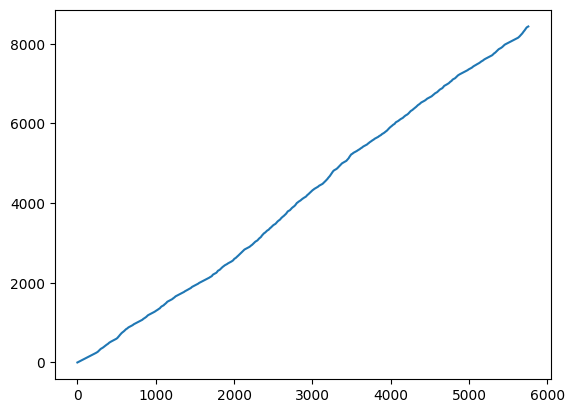

In [21]:
plt.plot(time_points)
plt.show()

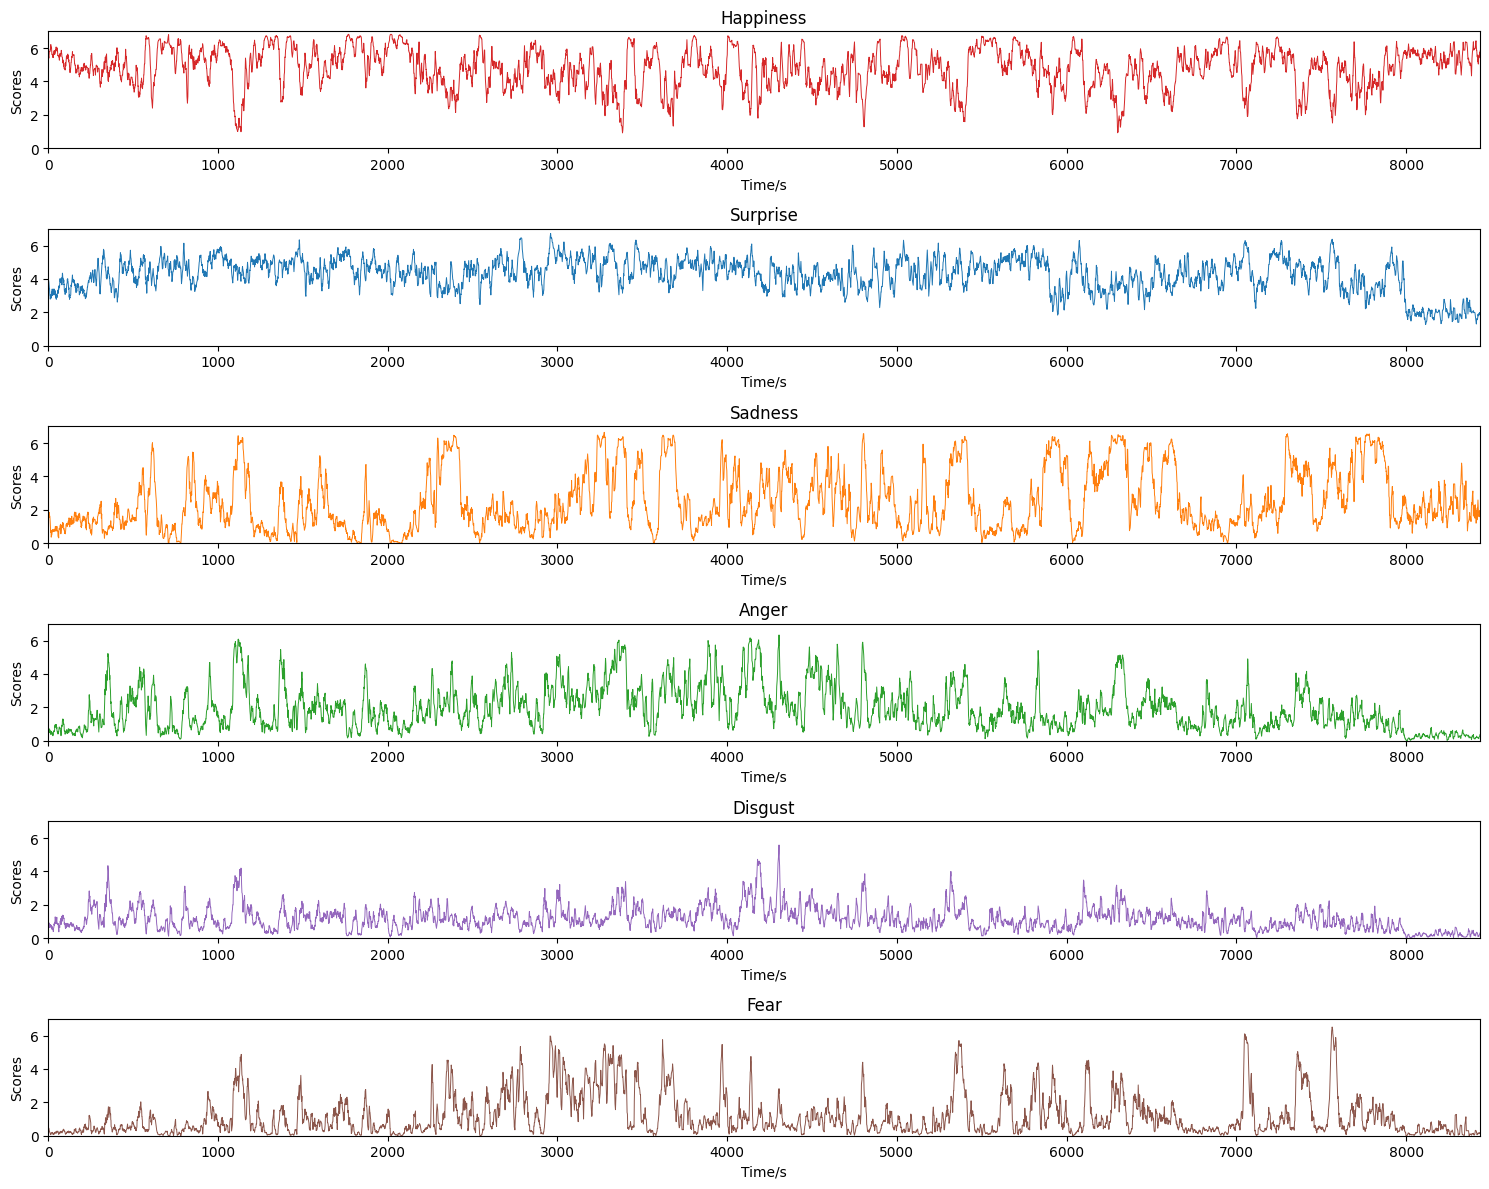

In [64]:
plot_scores(smooth_scores(np.array(socre_list),time_points),time_points)